# When Vegas rings the register louder, do the casino stocks run? 🎲
### 'Strip revenue leads the casino stocks' — the sector's favourite crystal ball, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leading_signal%3F: Not_supported](https://img.shields.io/badge/Leading_signal%3F-Not_supported-8b949e?style=flat-square)

Every month Nevada reports how much money the Las Vegas **Strip** casinos won from gamblers — the *gross gaming revenue*, or **GGR**. The folklore on trading desks and cable-TV 'casino watch' segments is that this number is the pulse of the whole business: when Strip revenue starts **accelerating**, the casino stocks — MGM, Caesars, Las Vegas Sands, Wynn, Boyd, Penn — are about to run.

It's a tidy story. It's also testable. This notebook asks three blunt questions: when Strip revenue speeds up, do the casino stocks really do better next? Does the revenue uptick actually come **first** (that's the whole pitch)? And if you *bought* the casinos every time revenue accelerated, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the lead/lag cross-correlation and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The Nevada Gaming Control Board publishes Strip GGR as monthly PDFs we can't fetch here, so we use a **hardcoded reconstruction** whose *yearly* totals match the published numbers (the ~$6.6B pre-COVID years, the 2020 shutdown, the record ~$8.8B of 2023–24) — public and faithful in aggregate, clearly labelled as a reconstruction. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vegas_gaming_win import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("casino cache present:", HAVE_REAL,
      "| GGR+basket months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-02-28', 'end': '2025-06-30', 'months': 281, 'years': 23.3, 'h1': (1, 185, 1.66, 2.31, 1.88, 59, 57, -0.2, 0.572), 'h3': (3, 183, 5.61, 5.16, 5.46, 66, 62, 0.09, 0.458), 'h6': (6, 181, 11.51, 12.36, 11.8, 64, 65, -0.1, 0.539), 'h12': (12, 181, 21.76, 31.91, 25.05, 66, 69, -0.72, 0.81), 'leadlag': {-6: 0.071, -5: 0.065, -4: 0.045, -3: -0.011, -2: -0.068, -1: -0.113, 0: -0.114, 1: -0.105, 2: -0.095, 3: -0.096, 4: -0.09, 5: -0.083, 6: -0.069}, 'overlay': (23.0, 0.49, 13.5, 0.51, 13.4, 0.5, 11), 'robust': [('k=1', 177, 23.81, 25.05, -0.27, 0.625), ('k=3', 181, 21.76, 25.05, -0.72, 0.81), ('k=6', 182, 19.8, 25.05, -1.15, 0.924), ('thr>+3%', 30, 1.61, 25.05, -4.08, 0.997), ('ex-COVID', 174, 22.87, 25.52, -0.62, 0.769)], 'syn': [(0.0, 172, 0.99, 0.5, 0.76, 0.178), (0.05, 172, 5.53, 3.06, 3.7, 0.0)]}


casino cache present: True | GGR+basket months: 281


## The answer first

| Question | Answer |
|---|---|
| When Strip revenue accelerates, do casino stocks do better? | **No.** Over the next year the basket averages **+21.8%** after a revenue uptick vs **+25.1%** normally — *lower*, not higher. The bullish tilt the folklore promises just isn't there. |
| Is any gap reliable? | **No.** Every horizon is a statistical tie (or the wrong sign), well inside the noise. |
| Does the revenue uptick come *first*? | **No — and this is the killer.** The revenue signal lines up best with a stock move that already happened **half a year earlier.** The stocks lead the revenue here, not the other way round. |
| So could you trade it? | **It gives up money.** 'Own casinos when revenue accelerates' earned **+13.4%/yr** vs **+23.0%** for just holding — the same risk-adjusted return, a third less time in the market. |

> Casinos and gambling revenue are obviously linked. But 'revenue tells you where the stocks go *next*' is a backward-looking report echoing a move the market already made — and acting on it costs you compounding.

## 1 · The claim

> *"Las Vegas Strip gaming revenue is the fundamental pulse of the casino business. When the monthly revenue run-rate turns up, the operators' earnings are accelerating and their stocks are about to follow — so buy the casino basket the moment Strip revenue starts climbing."*

There's a respectable backbone: Strip GGR really is the top-line the casino operators earn off. Fewer visitors and lower spend genuinely hurt them. The trading leap is the part we test — that a revenue *uptick* arrives early enough, and cleanly enough, to be a **tradable** signal for the equities.

## 2 · So what?

If true, this would be a gift: a free, public, monthly government number that tells you when to own an entire sector. But 'the pulse' hides a trap. The **stock market is forward-looking** — casino shares trade on *next quarter's* bookings, room rates and macro, priced in by analysts long before the backward-looking revenue tally is even tabulated (the report lands about **five weeks after** the month it covers). So a revenue number that lines up with the stocks might not be *predicting* them at all — it might just be **confirming**, weeks late, a move the market already made. The difference between *leads* and *echoes* is the difference between an edge and a mirage.

## 3 · How would we even know?

We line up **23 years** (2002–2025, 281 months) of monthly Strip revenue against an equal-weight casino basket, and:

1. **Split the months.** Because revenue is wildly seasonal (March and summer peaks) and had a total COVID shutdown, we track the **trailing-12-month revenue run-rate** and call it **rising** when it's above where it was three months ago. Compare what the basket did next (1/3/6/12 months) after rising-revenue months vs all months.
2. **Check the timing.** The crucial test: slide the revenue signal forward and backward against the stocks and find *where* they line up best. If revenue truly **leads**, the strongest link shows up at a **positive lead** (revenue first, stocks later).
3. **Try to trade it.** Own the basket whenever revenue is accelerating, sit in cash otherwise, pay realistic costs — and see if it beats just buying and holding.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the Strip revenue run-rate over two decades — the mid-2000s build, the 2008–09 dip, the off-the-chart **COVID shutdown** of 2020 (revenue literally near zero for two months while the casinos were closed), and the record 2022–24 boom. Revenue clearly *knows* about the cycle. The question is whether it knows **early**.

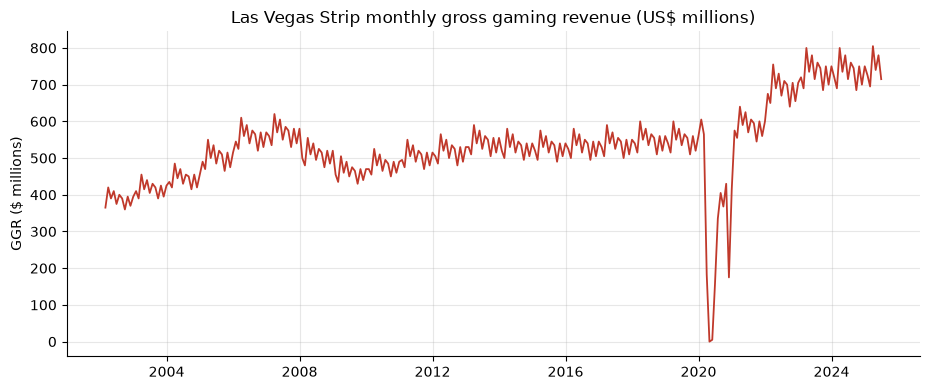

trough (COVID): 0 $M around 2020-04-30 | recent peak: 805 $M


In [2]:
if HAVE_REAL:
    g = F['ggr']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(g.index, g.values, c=RED, lw=1.3)
    ax.set_title('Las Vegas Strip monthly gross gaming revenue (US$ millions)')
    ax.set_ylabel('GGR ($ millions)')
    plt.tight_layout(); plt.show()
    print('trough (COVID):', int(g.min()), '$M around', g.idxmin().date(),
          '| recent peak:', int(g.max()), '$M')
else:
    print('no cache — see docs/results.md; Strip GGR ~0 in Apr-May 2020 (closure), ~$800M peak months 2023-24')

**Now the payoff.** For each horizon, the average forward basket return in **rising-revenue** months next to the return on an **average** month. The folklore predicts the green bars sit *above* the grey ones.

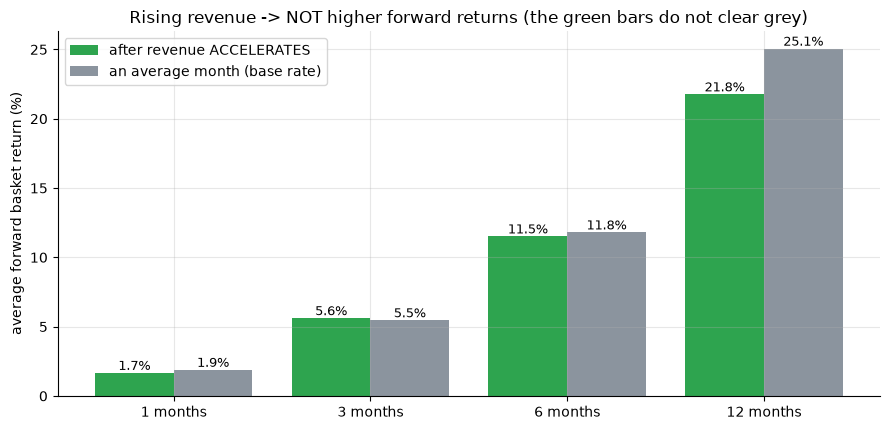

12-month: rising 21.8% vs base 25.1%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    ris = [r['rising_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    ris = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, ris, .4, color=GREEN, label='after revenue ACCELERATES')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward basket return (%)')
ax.set_title('Rising revenue -> NOT higher forward returns (the green bars do not clear grey)')
for i,(a,b) in enumerate(zip(ris,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('12-month: rising', f'{ris[-1]:.1f}%', 'vs base', f'{base[-1]:.1f}%')

The tilt the story needs simply isn't there. At 12 months rising-revenue returns (**+21.8%**) are actually *below* the base rate (**+25.1%**), and the basket is *up* slightly *less* often (**66%** vs **69%**). This is the opposite of a bullish leading signal. Hold that thought; the *next* chart shows **why**.

**The crucial test: does the revenue uptick come *first*?** We slide the revenue signal forward and backward against the stocks and measure how tightly they move together. A real leading signal would show its strongest *upward* link at a **positive lead** (revenue leads → green bar on the right). Watch where the green actually is.

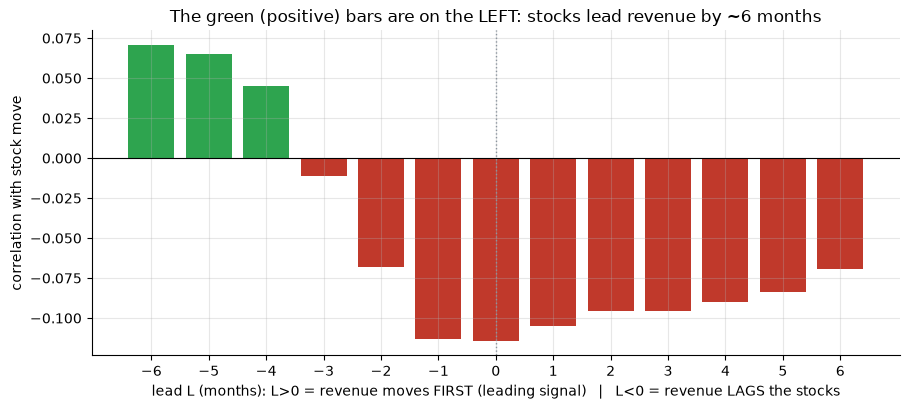

strongest POSITIVE link at L=-6 months (stocks moved FIRST here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if c>0 else RED for c in cs]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = revenue moves FIRST (leading signal)   |   L<0 = revenue LAGS the stocks')
ax.set_ylabel('correlation with stock move'); ax.set_xticks(Ls)
ax.set_title('The green (positive) bars are on the LEFT: stocks lead revenue by ~6 months')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'strongest POSITIVE link at L={Ls[imax]} months (stocks moved FIRST here)')

There it is. The only *positive* bars sit on the **left** (peak **+0.07 at L = −6**) — the revenue signal lines up best with a stock move that happened **half a year earlier**. On the right, where a true leading signal would live (revenue moving first), the bars are all **negative**. **Revenue isn't leading the stocks — it's trailing them.** The casino shares turn on expectations; the revenue report just confirms it, weeks late.

**Could you trade it anyway?** Suppose you owned the casino basket every month revenue was accelerating and sat in cash otherwise. Here's that strategy's growth vs just buying and holding the basket.

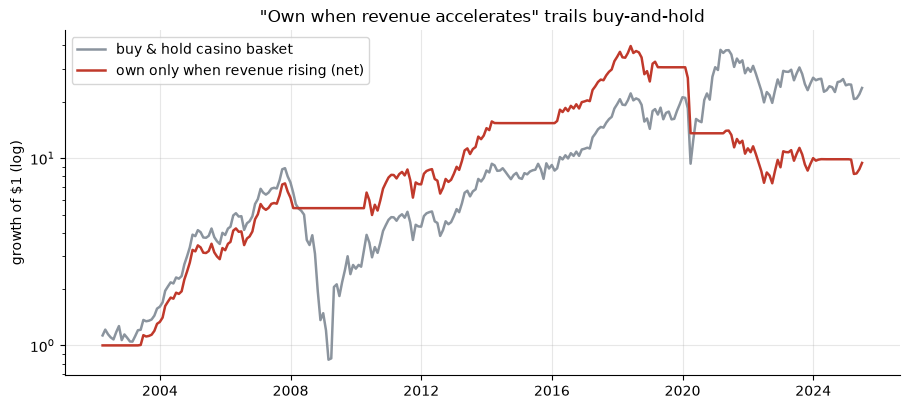

final $1 -> buy&hold 23.7x  vs  overlay 9.4x


In [5]:
if HAVE_REAL:
    import pandas as pd
    rising = st.rising_mask(F); pos = rising.astype(float).shift(1)
    rr = F['basket'].pct_change()
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold casino basket')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='own only when revenue rising (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Own when revenue accelerates" trails buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The overlay ends up **well below** buy-and-hold — **+13.4%/yr** vs **+23.0%/yr** net — for essentially the **same Sharpe** (0.50 vs 0.49). All the rule does is sit in cash a third of the time; it trims your exposure without buying any skill. The signal doesn't help — it just **de-risks you into a smaller pile.**

## 5 · The verdict

- **Signal — None.** Rising Strip revenue does *not* precede stronger casino-stock returns — at every horizon the tilt is flat or slightly *negative*, and when revenue accelerates **hardest** the next year is actively *worse*. There's no bullish leading signal here.
- **Tradability — Mirage.** Owning on rising revenue **ties** buy-and-hold on Sharpe while giving up ~10 points of annual return. Nothing to deploy — it's just less beta.
- **Leading signal? — Not supported.** The revenue uptick lines up with a stock move that already happened half a year earlier. The stocks **lead**; the revenue report **echoes**. The one word that makes the pitch — *leading* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even the *shape* of the signal is backwards for trading. The revenue run-rate is rising in **two-thirds of months** (a slow, smooth series drifts up most of the time), so 'own when rising' is really just 'own most of the time, minus a bit' — less exposure, not smarter exposure. And the one moment the signal fires **hardest** — the fastest revenue surges, like the 2021–22 post-COVID boom — is exactly when the casino stocks are *topping out* and about to sell off (that's why filtering to the biggest accelerations makes the next-year return sharply **negative**). There is no version of 'buy casinos when Vegas revenue accelerates' that both fires early and makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of a famous macro 'leading' number and finds the same shape: a coincident-to-lagging echo, not a crystal ball.
- **More macro pulses.** [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/) and [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) put other celebrated gauges through the same wringer.
- **Build your own.** Swap the equal-weight basket for a single name (MGM), or pair revenue with a *price* trend filter — the lead/lag picture barely budges: a backward-looking report can't be made to lead a forward-looking stock by resampling it differently.

*Think Vegas revenue leads the casinos? Show the lead/lag chart turning **green on the right** (positive lead) — then we'll talk.*